In [295]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt;

## Reading the data 

In [296]:
data=pd.read_csv('./UpdatedResumeDataSet.csv')

In [297]:
data.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [298]:
data.shape

(962, 2)

In [299]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  962 non-null    object
 1   Resume    962 non-null    object
dtypes: object(2)
memory usage: 15.2+ KB


In [300]:
data.isnull().sum()

Category    0
Resume      0
dtype: int64

In [301]:
data.columns

Index(['Category', 'Resume'], dtype='object')

In [302]:
data['Category'].value_counts()

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Blockchain                   40
ETL Developer                40
Operations Manager           40
Data Science                 40
Sales                        40
Mechanical Engineer          40
Arts                         36
Database                     33
Electrical Engineering       30
Health and fitness           30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
SAP Developer                24
Civil Engineer               24
Advocate                     20
Name: count, dtype: int64

## Visualizing the data

In [303]:
import seaborn as sns;

<Figure size 1500x1000 with 0 Axes>

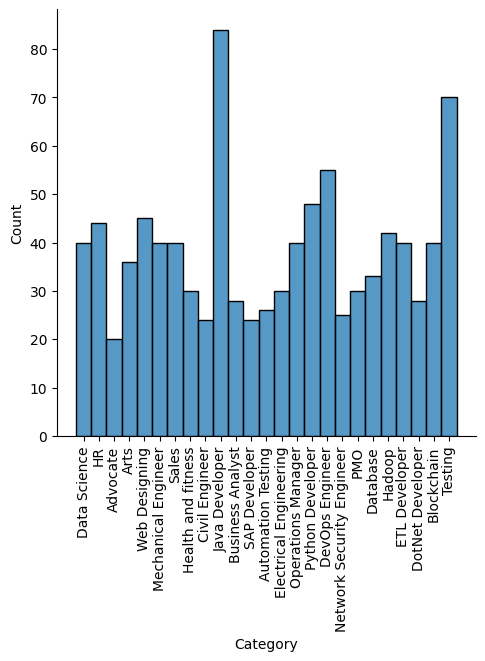

In [304]:
plt.figure(figsize=(15,10))
sns.displot(data['Category'])
plt.xticks(rotation=90)
plt.show()

In [305]:
counts=data['Category'].value_counts()
labels=data['Category'].unique()

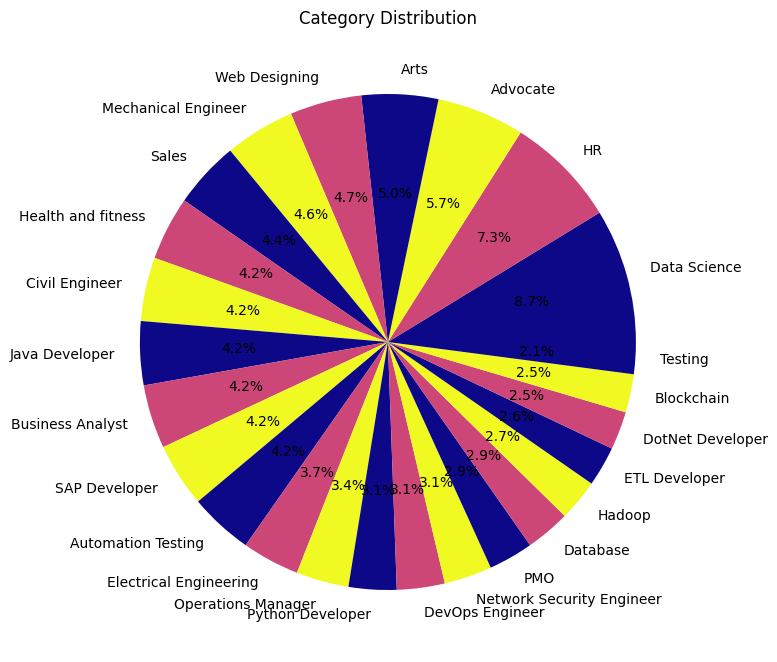

In [306]:
plt.figure(figsize=(8,10))
plt.pie(counts, labels=labels,autopct='%1.1f%%',colors=plt.cm.plasma(np.linspace(0,1,3)))
plt.title("Category Distribution")
plt.show()

In [307]:
print(data['Resume'][0])

Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details 

Data Science Assurance Associate 

Data Science Assurance Associate - Ernst & Young LLP
Skill Details 
JAVASCRIPT- Exprience - 24 months
jQuery- Exprience - 24 months
Python- Exprience - 24 monthsCompany Details 
company - Ernst & Young LLP
description - Fraud Investigations and Dispute Services   Assur

## Cleaning data

In [308]:
import re

def cleanResume(text):
    text=re.sub('http\S+\s','',text)
    text=re.sub('@\S+','',text)
    text=re.sub('#\S+','',text)
    clean_text = re.sub(r'[^A-Za-z0-9 ]+', '', text)  
    return clean_text




<>:4: SyntaxWarning: invalid escape sequence '\S'
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:6: SyntaxWarning: invalid escape sequence '\S'
<>:4: SyntaxWarning: invalid escape sequence '\S'
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:6: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Kanishka\AppData\Local\Temp\ipykernel_24452\665423906.py:4: SyntaxWarning: invalid escape sequence '\S'
  text=re.sub('http\S+\s','',text)
C:\Users\Kanishka\AppData\Local\Temp\ipykernel_24452\665423906.py:5: SyntaxWarning: invalid escape sequence '\S'
  text=re.sub('@\S+','',text)
C:\Users\Kanishka\AppData\Local\Temp\ipykernel_24452\665423906.py:6: SyntaxWarning: invalid escape sequence '\S'
  text=re.sub('#\S+','',text)


In [309]:
data['Resume']=data['Resume'].apply(cleanResume)

## Performing stemming using porterstemmer

In [310]:
from nltk.stem import PorterStemmer
ps=PorterStemmer()

In [311]:
def stem(text):
    words = text.split()  # Tokenize by splitting at spaces
    l = [ps.stem(word.lower()) for word in words]  # Stem each word
    return ' '.join(l)  # Join back into a sentence


In [312]:
data['Resume']=data['Resume'].apply(stem)

## Coverting text to vectors

In [313]:
from sklearn.feature_extraction.text import CountVectorizer;
cv=CountVectorizer(stop_words='english',ngram_range=(1,3),max_features=5000)


In [314]:
X=data['Resume']
Y=data['Category']

In [315]:
X.isnull().sum()

0

In [316]:
Y.isnull().sum()

0

## Test Train And Split The data

In [317]:
from sklearn.model_selection import train_test_split

In [318]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.33,random_state=0)

- Convert train text data to vectors
- Convert test text data to vectors

In [319]:
X_train_vec=cv.fit_transform(X_train).toarray()
X_test_vec=cv.transform(X_test).toarray()

In [320]:
X_train_vec,X_test_vec

(array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=int64),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=int64))

## Building the Model

In [321]:
from sklearn.neighbors import KNeighborsClassifier
knc=KNeighborsClassifier(n_neighbors=3)


In [322]:
knc.fit(X_train_vec,Y_train)

KNeighborsClassifier(n_neighbors=3)

In [323]:
y_pred=knc.predict(X_test_vec)
# print(y_pred)

## FIND ACCUARCY OF MODEL'S PREDICITIONS

In [324]:
from sklearn.metrics import accuracy_score

In [325]:
ac=accuracy_score(Y_test,y_pred)
print("Accuracy:",ac)

Accuracy: 0.9622641509433962


## Saving the model

In [326]:
import pickle
pickle.dump(cv,open('vector.pkl','wb'))
pickle.dump(knc,open('model.pkl','wb'))

## Testing the model

In [329]:
text='''
"Software Proficiency: â¢ Languages: Basics of C, SQL, PL/SQL,JAVA,JAVAEE,Javascript,HTML,CSS,jquery,mysql,Spring ,Hibernate. â¢ Software Tools: Xillinx, Modelsim, Matlab, Multisim. â¢ Operating Systems: Windows XP, Vista, 07, 08, Ubuntu. Project Profile: B.E. Project FPGA Implementation of Team Size: 4. Role: Programmer. AES Algorithm AES is Advanced Encryption Standard which is used in cryptography by which we can protect our data. It encrypted by a Secret Key. T.E. project Sorting Robot. Team Size: 3. Role: Mechanism designer. The TCS 230 sensor sorts the RGB color balls according to their color. Diploma Project RFID Based Student Team Size: 4. Role: Interface. Attendance System Using GSM. In this student show RFID card of his own and then message send via GSM to their parent that his ward is present.Education Details 
May 2016 B.E. Savitribai Phule Pune, Maharashtra Pune University
March 2010 S.S.C   Maharashtra Board
DevOps Engineer 


Skill Details 
C- Exprience - 6 months
C++- Exprience - 6 months
Sql- Exprience - 6 months
Pl/Sql- Exprience - 6 months
Core Java- Exprience - 6 months
Javascript- Exprience - Less than 1 year months
HTML- Exprience - Less than 1 year months
CSS- Exprience - Less than 1 year months
Jquery- Exprience - Less than 1 year months
JavaEE- Exprience - Less than 1 year months
Mysql- Exprience - Less than 1 year months
Python- Exprience - 6 monthsCompany Details 
company - Parkar Consulting and Labs
description - I'm working on the DevOps team in Parkar Consulting and Labs. I have hands on the AWS as well as Python"


'''

In [330]:
cv=pickle.load(open('vector.pkl','rb'))
knc=pickle.load(open('model.pkl','rb'))


## cleaning the resume text
text=cleanResume(text)
## apply stemming to text
text=stem(text)


## vectorize the data 
vec=cv.transform([text])

## predicting the output
y_predict=knc.predict(vec)

print(y_predict[0])



DevOps Engineer
